# 17 - Mapper Node Stability Report

This notebook is deliberately thin. It reads the frozen outputs from
`scripts/run_mapper_node_stability.py` and reports the primary decision,
dataset-level effects, stable tracks, metadata-shuffle checks, and saved
Beans patch-atlas records.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

for candidate in [Path.cwd(), Path.cwd().parent]:
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

ROOT = Path.cwd()
if not (ROOT / "notebooks").exists() and (ROOT.parent / "notebooks").exists():
    ROOT = ROOT.parent

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

from notebook_utils.diagnostic_workbench import load_cached_flux_clouds
from notebook_utils.encoder_explorer import DEFAULT_IMAGE_DIR, approximate_patch, load_project_images

## 1. Load Frozen Outputs

In [2]:
OUTPUT_DIR = Path(os.environ.get("MAPPER_NODE_STABILITY_OUTPUT", ROOT / "outputs" / "mapper_node_stability_v1"))
if not OUTPUT_DIR.is_absolute():
    OUTPUT_DIR = ROOT / OUTPUT_DIR
if not OUTPUT_DIR.exists():
    raise FileNotFoundError(f"Run scripts/run_mapper_node_stability.py first. Missing: {OUTPUT_DIR}")

config = json.loads((OUTPUT_DIR / "config_snapshot.json").read_text())
verdict = json.loads((OUTPUT_DIR / "verdict.json").read_text())
counts = pd.read_csv(OUTPUT_DIR / "counts.csv")
paired = pd.read_csv(OUTPUT_DIR / "paired_primary.csv")
tracks = pd.read_csv(OUTPUT_DIR / "tracks.csv")
matches = pd.read_csv(OUTPUT_DIR / "matches.csv")
run_stats = pd.read_csv(OUTPUT_DIR / "run_stats.csv")
shuffles = pd.read_csv(OUTPUT_DIR / "metadata_shuffle_counts.csv") if (OUTPUT_DIR / "metadata_shuffle_counts.csv").exists() else pd.DataFrame()
atlas_records = pd.read_csv(OUTPUT_DIR / "patch_atlas_records.csv") if (OUTPUT_DIR / "patch_atlas_records.csv").exists() else pd.DataFrame()

display(Markdown(f"Output directory: `{OUTPUT_DIR.relative_to(ROOT)}`"))
display(
    pd.DataFrame(
        [
            {"field": "status", "value": verdict.get("status")},
            {"field": "mean_delta", "value": verdict.get("mean_delta")},
            {"field": "bootstrap_ci_95", "value": verdict.get("bootstrap_ci_95")},
            {"field": "positive_datasets", "value": f"{verdict.get('positive_datasets')} / {verdict.get('n_datasets')}"},
            {"field": "metadata_shuffle_wins", "value": f"{verdict.get('metadata_shuffle_wins')} / {verdict.get('n_datasets')}"},
        ]
    )
)

Output directory: `outputs/mapper_node_stability_v1`

,field,value
0,status,pass
1,mean_delta,8.0
2,bootstrap_ci_95,"[2.0, 13.0]"
3,positive_datasets,3 / 3
4,metadata_shuffle_wins,3 / 3


## 2. Primary Decision

The registered statistic is:

`stable_enriched_track_count_delta = observed_count - max(control_counts)`

,dataset,observed_count,max_control_count,hardest_control,stable_enriched_track_count_delta,metadata_shuffle_q95,beats_metadata_shuffle
0,beans_local,5,3,norm_random_directions,2,2.0,True
1,cifar10,12,3,norm_random_directions,9,2.0,True
2,fashion_mnist,16,3,norm_random_directions,13,3.0,True


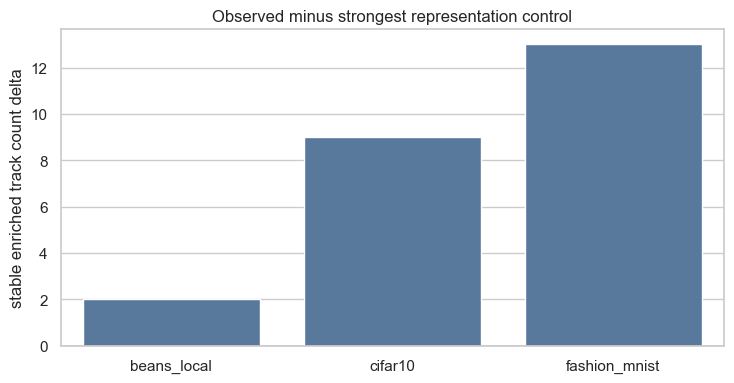

In [3]:
display(paired)

if not paired.empty:
    fig, ax = plt.subplots(figsize=(7.5, 4.0))
    sns.barplot(data=paired, x="dataset", y="stable_enriched_track_count_delta", color="#4c78a8", ax=ax)
    ax.axhline(0, color="0.25", linewidth=1)
    ax.set_title("Observed minus strongest representation control")
    ax.set_ylabel("stable enriched track count delta")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

## 3. Counts By Condition

In [4]:
cols = [
    "dataset",
    "representation",
    "sample_kind",
    "baseline_group",
    "stable_track_count",
    "stable_enriched_track_count",
    "median_best_jaccard_stable",
    "mean_label_purity_excess_stable",
    "metadata_shuffle_stable_enriched_count_q95",
    "metadata_shuffle_win",
]
display(counts[[col for col in cols if col in counts.columns]].sort_values(["dataset", "representation", "baseline_group", "sample_kind"]))

,dataset,representation,sample_kind,baseline_group,stable_track_count,stable_enriched_track_count,median_best_jaccard_stable,mean_label_purity_excess_stable,metadata_shuffle_stable_enriched_count_q95,metadata_shuffle_win
0,beans_local,flux_vae,observed,observed,26,5,0.375406,0.095614,2.0,True
1,beans_local,flux_vae,channel_shuffle,representation_control,26,0,0.327092,0.055479,2.0,False
2,beans_local,flux_vae,norm_random_directions,representation_control,23,3,0.189815,0.081341,2.0,True
9,beans_local,raw_patches,raw_patches,specificity_baseline,30,8,0.435897,0.102511,2.0,True
3,cifar10,flux_vae,observed,observed,26,12,0.427178,0.203875,2.0,True
4,cifar10,flux_vae,channel_shuffle,representation_control,24,0,0.328238,0.049748,2.0,False
5,cifar10,flux_vae,norm_random_directions,representation_control,29,3,0.194667,0.081231,2.0,True
6,fashion_mnist,flux_vae,observed,observed,27,16,0.458333,0.220917,3.0,True
7,fashion_mnist,flux_vae,channel_shuffle,representation_control,23,2,0.311828,0.066844,2.0,False
8,fashion_mnist,flux_vae,norm_random_directions,representation_control,33,3,0.210084,0.095394,2.0,True


## 4. Mapper Run Statistics

In [5]:
stat_cols = [
    "dataset",
    "representation",
    "sample_kind",
    "seed",
    "nodes",
    "edges",
    "graph_h1_rank",
    "coverage_fraction",
    "weighted_label_purity",
]
display(run_stats[[col for col in stat_cols if col in run_stats.columns]].round(3).head(80))

,dataset,representation,sample_kind,seed,nodes,edges,graph_h1_rank,coverage_fraction,weighted_label_purity
0,beans_local,flux_vae,observed,72,88,264,178,0.858,0.460
1,beans_local,flux_vae,observed,73,92,269,179,0.868,0.482
2,beans_local,flux_vae,observed,74,80,248,169,0.865,0.464
3,beans_local,flux_vae,observed,75,87,262,178,0.872,0.475
4,beans_local,flux_vae,channel_shuffle,72,69,209,141,0.915,0.401
5,beans_local,flux_vae,channel_shuffle,73,78,268,191,0.930,0.403
6,beans_local,flux_vae,channel_shuffle,74,70,202,134,0.933,0.401
7,beans_local,flux_vae,channel_shuffle,75,69,207,141,0.934,0.394
8,beans_local,flux_vae,norm_random_directions,72,73,256,184,0.925,0.420
9,beans_local,flux_vae,norm_random_directions,73,67,212,148,0.923,0.431


## 5. Stable Tracks

In [6]:
stable_cols = [
    "dataset",
    "representation",
    "sample_kind",
    "reference_node_id",
    "reference_size",
    "recurrence",
    "median_best_jaccard",
    "label_purity",
    "label_purity_excess",
    "dominant_label",
    "dominant_image_fraction",
    "spatial_radius",
    "is_stable_track",
    "is_stable_enriched_track",
]
stable = tracks[tracks["is_stable_track"]].copy()
sort_cols = [col for col in ["is_stable_enriched_track", "label_purity_excess", "median_best_jaccard", "reference_size"] if col in stable.columns]
if sort_cols:
    stable = stable.sort_values(sort_cols, ascending=False)
display(stable[[col for col in stable_cols if col in stable.columns]].head(40).round(3))

,dataset,representation,sample_kind,reference_node_id,reference_size,recurrence,median_best_jaccard,label_purity,label_purity_excess,dominant_label,dominant_image_fraction,spatial_radius,is_stable_track,is_stable_enriched_track
246,cifar10,flux_vae,observed,58,24,1.0,0.500,0.708,0.591,ship,0.667,12.373,True,True
528,fashion_mnist,flux_vae,observed,10,34,1.0,0.349,0.618,0.507,Shirt,0.324,8.190,True,True
247,cifar10,flux_vae,observed,66,24,1.0,0.500,0.583,0.466,deer,0.250,13.213,True,True
494,fashion_mnist,flux_vae,observed,67,33,1.0,0.574,0.576,0.465,Sandal,0.273,10.383,True,True
293,cifar10,flux_vae,observed,54,28,1.0,0.243,0.571,0.454,deer,0.214,11.062,True,True
513,fashion_mnist,flux_vae,observed,14,65,1.0,0.455,0.523,0.413,Shirt,0.231,9.501,True,True
270,cifar10,flux_vae,observed,104,23,1.0,0.400,0.522,0.405,horse,0.478,11.063,True,True
17,beans_local,flux_vae,observed,77,30,1.0,0.400,0.700,0.349,angular_leaf_spot,0.200,7.919,True,True
530,fashion_mnist,flux_vae,observed,29,24,1.0,0.326,0.458,0.348,Coat,0.208,9.163,True,True
520,fashion_mnist,flux_vae,observed,60,22,1.0,0.394,0.455,0.344,Dress,0.227,9.684,True,True


## 6. Metadata-Shuffle Null

,,count,mean,std,min,25%,50%,75%,max
dataset,sample_kind,,,,,,,,
beans_local,observed,64.0,0.688,0.774,0.0,0.0,1.0,1.0,3.0
cifar10,observed,64.0,0.844,0.840,0.0,0.0,1.0,1.0,3.0
fashion_mnist,observed,64.0,1.172,1.077,0.0,0.0,1.0,2.0,5.0


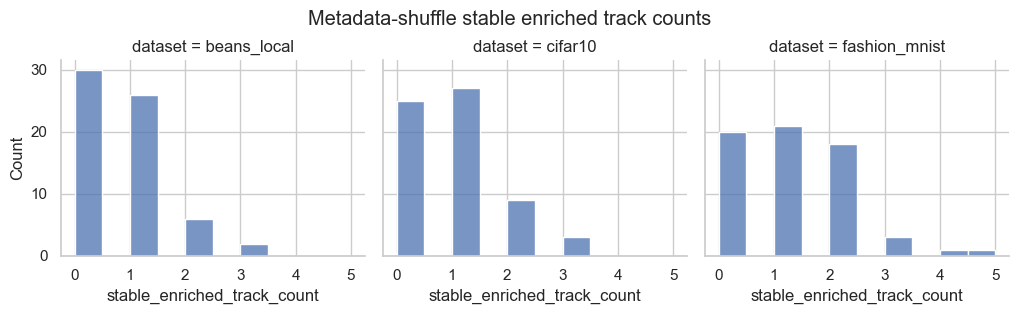

In [7]:
if shuffles.empty:
    display(Markdown("No metadata-shuffle table was saved."))
else:
    observed_shuffles = shuffles[shuffles["baseline_group"] == "observed"].copy()
    display(observed_shuffles.groupby(["dataset", "sample_kind"])["stable_enriched_track_count"].describe().round(3))
    if not observed_shuffles.empty:
        grid = sns.displot(
            data=observed_shuffles,
            x="stable_enriched_track_count",
            col="dataset",
            col_wrap=3,
            bins=10,
            height=3.0,
            aspect=1.15,
        )
        grid.fig.suptitle("Metadata-shuffle stable enriched track counts", y=1.04)
        plt.show()

## 7. Beans Patch Atlas Records

These cells are not recomputing Mapper. They render the saved
`source_index` records from the experiment outputs.

,dataset,representation,sample_kind,baseline_group,reference_node_id,patch_rank,source_index,image_id,label,h,w,recurrence,median_best_jaccard,reference_size,label_purity,label_purity_excess,dominant_image_fraction,spatial_radius,is_stable_track,is_stable_enriched_track
0,beans_local,flux_vae,observed,observed,70,1,5689,5,healthy,17,25,1.0,0.483146,63,0.555556,0.204646,0.126984,9.744469,True,True
1,beans_local,flux_vae,observed,observed,70,2,9730,9,angular_leaf_spot,16,2,1.0,0.483146,63,0.555556,0.204646,0.126984,9.744469,True,True
2,beans_local,flux_vae,observed,observed,70,3,3155,3,angular_leaf_spot,2,19,1.0,0.483146,63,0.555556,0.204646,0.126984,9.744469,True,True
3,beans_local,flux_vae,observed,observed,70,4,30251,29,healthy,17,11,1.0,0.483146,63,0.555556,0.204646,0.126984,9.744469,True,True
4,beans_local,flux_vae,observed,observed,70,5,42992,41,healthy,31,16,1.0,0.483146,63,0.555556,0.204646,0.126984,9.744469,True,True
5,beans_local,flux_vae,observed,observed,70,6,20546,20,healthy,2,2,1.0,0.483146,63,0.555556,0.204646,0.126984,9.744469,True,True
6,beans_local,flux_vae,observed,observed,77,1,37145,36,angular_leaf_spot,8,25,1.0,0.400000,30,0.700000,0.349091,0.200000,7.919348,True,True
7,beans_local,flux_vae,observed,observed,77,2,422,0,angular_leaf_spot,13,6,1.0,0.400000,30,0.700000,0.349091,0.200000,7.919348,True,True
8,beans_local,flux_vae,observed,observed,77,3,16017,15,angular_leaf_spot,20,17,1.0,0.400000,30,0.700000,0.349091,0.200000,7.919348,True,True
9,beans_local,flux_vae,observed,observed,77,4,23220,22,bean_rust,21,20,1.0,0.400000,30,0.700000,0.349091,0.200000,7.919348,True,True


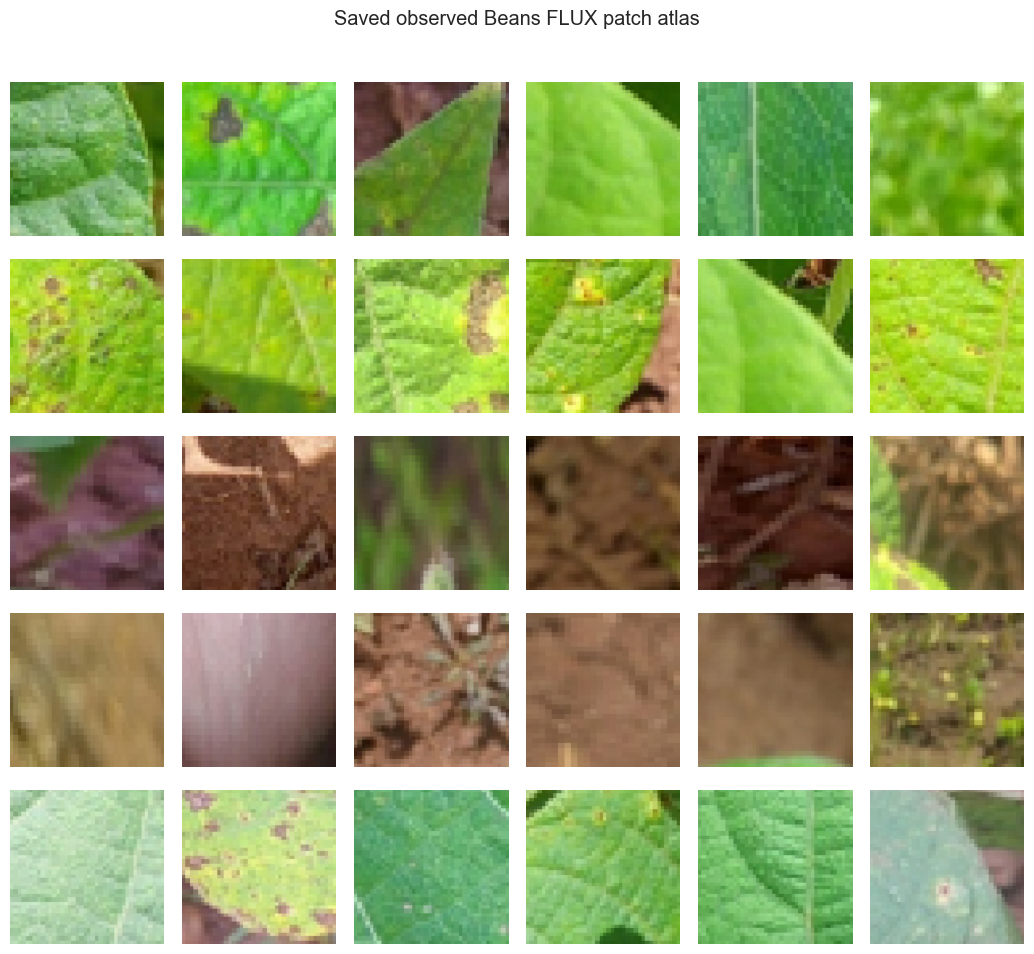

In [8]:
def plot_saved_atlas(records: pd.DataFrame, max_nodes: int = 8, patches_per_node: int = 6) -> None:
    if records.empty:
        display(Markdown("No patch-atlas records were saved."))
        return
    flux_clouds = load_cached_flux_clouds()
    if "beans_local" not in flux_clouds:
        display(Markdown("Beans FLUX cache is unavailable, so patches cannot be rendered."))
        return
    cloud = flux_clouds["beans_local"]
    image_dir = os.environ.get("TOKENIZER_IMAGE_DIR", str(DEFAULT_IMAGE_DIR))
    n_images = int(cloud.token_metadata["image_id"].max()) + 1
    images, _ = load_project_images(n_images=n_images, image_dir=image_dir)

    records = records[
        (records["dataset"] == "beans_local")
        & (records["representation"] == "flux_vae")
        & (records["sample_kind"] == "observed")
    ].copy()
    if records.empty:
        display(Markdown("No observed Beans FLUX atlas records were saved."))
        return
    node_ids = records["reference_node_id"].drop_duplicates().head(max_nodes).astype(int).tolist()
    fig, axes = plt.subplots(len(node_ids), patches_per_node, figsize=(1.75 * patches_per_node, 1.9 * len(node_ids)))
    axes = np.asarray(axes).reshape(len(node_ids), patches_per_node)
    context = 2 if cloud.grid_shape[0] >= 16 else 1
    for row_i, node_id in enumerate(node_ids):
        node_records = records[records["reference_node_id"] == node_id].head(patches_per_node)
        label_parts = [f"node {node_id}"]
        first = node_records.iloc[0]
        if "recurrence" in first:
            label_parts.append(f"rec={first['recurrence']:.2f}")
        if "median_best_jaccard" in first:
            label_parts.append(f"J={first['median_best_jaccard']:.2f}")
        if "label_purity_excess" in first:
            label_parts.append(f"excess={first['label_purity_excess']:.2f}")
        for col_i in range(patches_per_node):
            ax = axes[row_i, col_i]
            if col_i < len(node_records):
                source_index = int(node_records.iloc[col_i]["source_index"])
                ax.imshow(approximate_patch(cloud, images, source_index, image_size=256, context_cells=context))
            ax.axis("off")
            if col_i == 0:
                ax.set_ylabel("\n".join(label_parts), rotation=0, ha="right", va="center", fontsize=8)
    fig.suptitle("Saved observed Beans FLUX patch atlas", y=1.01)
    plt.tight_layout()
    plt.show()


display(atlas_records.head(30))
plot_saved_atlas(atlas_records)

## 8. Readout

This report should be read as a pass/fail for the current Mapper-node
claim, not for the whole project. A fail means the current node-stability
criterion does not beat the strongest matched control under the frozen
rules. A pass means Mapper has earned a more serious role as a local
representation diagnostic.